# Brain Tumor detection
Categories -
- `glioma`:0
- `meningioma`:1
- `notumor`:2
- `pituitary`:3

divided in test and training sets in the folders

The Model is fine tuned on a ResNet model and gave an accuracy of 0.7025 on the test dataset after training for 10 epochs

The trained model weights are stored in the `ResNetFineTuned.h5` and `ResNetFineTuned.keras` file

In [184]:
classNames=['glioma_tumor','meningioma_tumor','no_tumor','pituitary_tumor']

In [166]:
import tensorflow as tf
from tensorflow.keras import layers
import os

### Get the datasets from `archive` folder

In [167]:
trainDataDir='archive/Training'
testDataDir='archive/Testing'
size=224
batch_size=32

train_ds = tf.keras.utils.image_dataset_from_directory(
    trainDataDir,
    batch_size=batch_size,
    # color_mode='grayscale', # Crucial for grayscale
    label_mode='categorical' # or 'categorical'
)


Found 5712 files belonging to 4 classes.


In [168]:

test_ds = tf.keras.utils.image_dataset_from_directory(
    testDataDir,
    batch_size=batch_size,
    shuffle=False,
    # color_mode='grayscale', # Crucial for grayscale
    label_mode='categorical' # or 'categorical'
)


Found 1311 files belonging to 4 classes.


In [169]:
def normalize_img(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def resize_img(image, label):
    image = tf.image.resize(image, [size, size])
    return image, label

train_ds = train_ds.map(resize_img,num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(normalize_img,num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)


In [170]:

test_ds = test_ds.map(resize_img,num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize_img,num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [171]:

for images, labels in train_ds:
    print(images.shape)
    print(labels.shape)
    break

(32, 224, 224, 3)
(32, 4)


### Define and Train the Model

- `ResNet101` trained on ImageNet -- originally has 1000 output classes
- We use `transfer learning` and use the weights of the ResNet 
- The conv layers are kept the same and the final fully connected (Dense) layers are re-trained
- One-Hot encoding used for final output
- `Softmax` used on final layer to output the probabilities of the classes

In [172]:
base = tf.keras.applications.ResNet101(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
)


In [173]:
base.trainable = False
x=base.output
x=layers.GlobalAveragePooling2D()(x)
x=layers.Dropout(0.5)(x)
x=layers.Dense(4,activation='linear')(x)

model=tf.keras.Model(inputs=base.input,outputs=x)

In [174]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.01),
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [175]:
es=tf.keras.callbacks.EarlyStopping(monitor='loss',patience=5,restore_best_weights=True)

In [176]:
history=model.fit(train_ds,epochs=10,callbacks=[es],validation_data=test_ds)

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 515s 3s/step - accuracy: 0.5091 - loss: 1.1474 - val_accuracy: 0.5667 - val_loss: 1.0316
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 523s 3s/step - accuracy: 0.6022 - loss: 0.9654 - val_accuracy: 0.6018 - val_loss: 1.0519
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 531s 3s/step - accuracy: 0.6239 - loss: 0.9248 - val_accuracy: 0.6636 - val_loss: 0.8935
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 544s 3s/step - accuracy: 0.6215 - loss: 0.9042 - val_accuracy: 0.6621 - val_loss: 0.9347
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 547s 3s/step - accuracy: 0.6420 - loss: 0.8881 - val_accuracy: 0.6453 - val_loss: 0.9006
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 549s 3s/step - accuracy: 0.6411 - loss: 0.8866 - val_accuracy: 0.6712 - val_loss: 0.9345
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 533s 3s/step - accuracy: 0.6446 - loss: 0.8764 - val_accuracy: 0.6629 - val_loss: 0.8484
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 469s 3s/step - accuracy: 0.6656 - loss: 0.8393 - val_accu

In [194]:
model.save('ResNetFineTuned.keras')
model.save('ResNetFineTuned.h5')

### Calculating different metrics and Evaluation Parameters

In [190]:
me=model.evaluate(test_ds)
print("Test Loss:",me[0])
print("Test Accuracy:",me[1])

41/41 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7025 - loss: 0.7840
Test Loss: 0.7840372323989868
Test Accuracy: 0.7025171518325806


In [179]:
import matplotlib.pyplot as plt
import seaborn as sns
pred=tf.nn.softmax(model.predict(test_ds,batch_size=1))
y_pred=tf.argmax(pred,axis=1)
y_true=tf.concat([y for x,y in test_ds],axis=0)
y_true=tf.argmax(y_true,axis=1)


41/41 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step


                  precision    recall  f1-score   support

    glioma_tumor       0.65      0.71      0.68       300
meningioma_tumor       0.62      0.33      0.43       306
        no_tumor       0.75      0.84      0.80       405
 pituitary_tumor       0.72      0.88      0.79       300

        accuracy                           0.70      1311
       macro avg       0.69      0.69      0.68      1311
    weighted avg       0.69      0.70      0.68      1311

[[214  50   6  30]
 [ 67 102  92  45]
 [ 35   3 342  25]
 [ 14  10  13 263]]


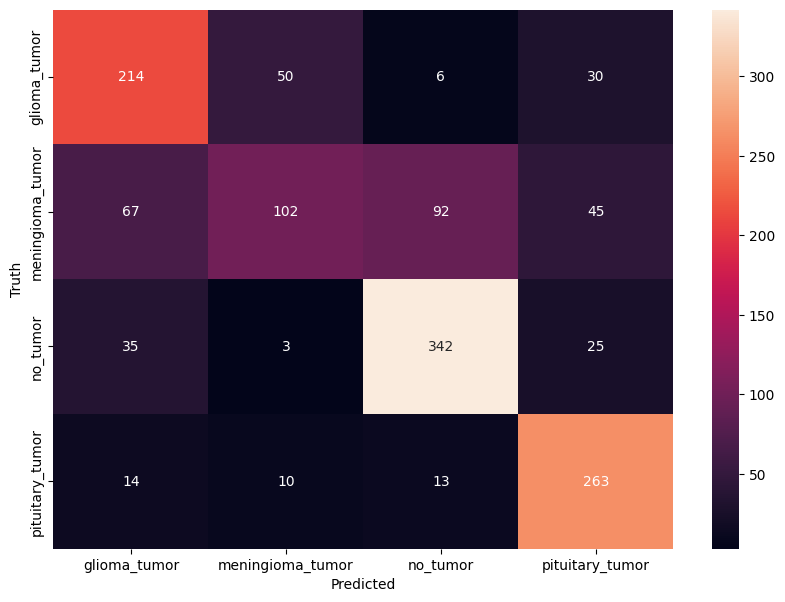

In [187]:
y_true_named = [classNames[i] for i in y_true]
y_pred_named = [classNames[i] for i in y_pred]

from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_true_named,y_pred_named))
print(confusion_matrix(y_true_named,y_pred_named))
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_true_named,y_pred_named,labels=classNames),annot=True,fmt='d',xticklabels=classNames,yticklabels=classNames)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()


### Conclusions

#### Observations

- Ok Ok accruacy on test set
- F1 score shows some **bad classification of meningioma**
- Recall of meningioma is not very gud
- No tumor and pituitary tumor have a good recall and precision
- glioma has OK OK recall and precision
- Confusion Matrix shows that the model is not as such biased towards a specefic class however very few were classified as meningioma
- only 165 were classified as meningioma however the dataset had cases

#### Further Work
- error analysis on the meningioma scans which are wrongly classified
- amend the model architecture to improve the meningioma classification

### Model Learning Curves and Layer Summaries

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


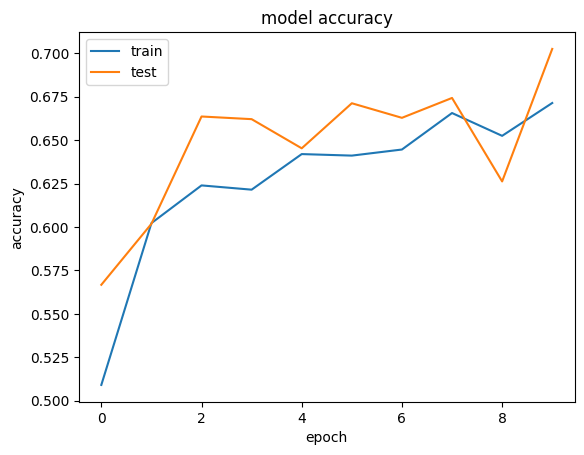

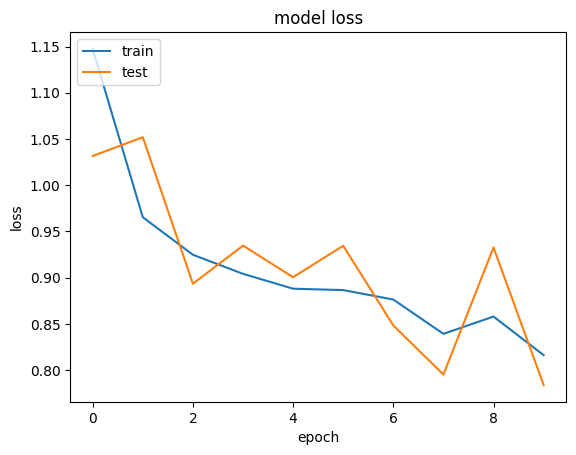

In [181]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [182]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 42,682,766 (162.82 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 42,658,176 (162.73 MB)

 Optimizer params: 16,394 (64.04 KB)